In [43]:
import numpy as np
import pandas as pd


def generate_market_simulator(
        n_points=100, 
        seed=42, 
        start_price=1.18
        ):
    """
    Generates raw market data (close prices only).

    CORE PRINCIPLE:
    - We do NOT predefine drift or volatility
    - We only generate raw stochastic movement
    - All structure is discovered later via:
        scale, distance, reversion, imbalance
    """

    np.random.seed(seed)

    # =========================================================
    # HOW DATA IS GENERATED (CONFIGURATION INTUITION)
    # =========================================================

    # n_points
    # → controls how long the market evolves
    # → more points = more regimes may appear naturally

    # seed
    # → controls randomness reproducibility
    # → same seed = same market behavior

    # start_price
    # → initial anchor of the system
    # → does NOT affect behavior, only vertical positioning

    # =========================================================
    # DATE GENERATION
    # =========================================================
    dates = pd.date_range(start="2015-01-01", periods=n_points, freq="D")

    # =========================================================
    # RAW MARKET MOVEMENT (NO STRUCTURE ASSUMED)
    # =========================================================
    # This is PURE noise:
    # → no drift (no directional bias)
    # → no volatility parameter (we do not label intensity here)
    #
    # IMPORTANT INTUITION:
    # You are not simulating "trend" or "volatility"
    # You are simulating only "step changes"

    returns = np.random.normal(
        loc=0.0,        # no directional assumption
        scale=0.002,    # fixed noise level (kept minimal and neutral)
        size=n_points
    )

    # =========================================================
    # PRICE CONSTRUCTION (PATH DEPENDENCY)
    # =========================================================
    # Each price depends on previous price + random step
    # → creates market-like structure emergently

    close = [start_price]

    for r in returns[1:]:
        next_price = close[-1] * (1 + r)
        close.append(next_price)

    # =========================================================
    # OUTPUT DATASET
    # =========================================================
    df = pd.DataFrame({
        "date": dates,
        "close": close
    })

    df = df.set_index("date")
    
    return df

In [44]:
def plot_market_regime_view(
          df: pd.DataFrame, 
          w: int = 7, 
          scale_window: int = 7
          ):
    
     # =========================
     # Structure (norm)
     # =========================
     df["roll_mean"]    = df["close"].rolling(w).mean()
     df["step_move"]    = df["close"].diff().abs()
     df["scale"]        = df["step_move"].rolling(scale_window).mean()
     df["0.25"]         = df["close"].rolling(w).quantile(0.25)
     df["0.50"]         = df["close"].rolling(w).quantile(0.50)
     df["0.75"]         = df["close"].rolling(w).quantile(0.75)
     df["iqr"]          = df["0.75"] - df["0.25"]
     df["n_above_mean"] = df["close"].rolling(w).apply(lambda x: (x > x.mean()).sum(), raw=False)
     df["n_below_mean"] = df["close"].rolling(w).apply(lambda x: (x < x.mean()).sum(), raw=False)

     n_data_points = 30
     result = df[["close", 
                  "roll_mean", 
                  "scale"
     ]].head(n_data_points).dropna().round(4)
     
     return result

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_price_norm_scale(df):
    """
    Plots:
    - Price (close)
    - Rolling mean (norm)
    - Scale (movement) on secondary axis
    """

    # =========================
    # Prepare data
    # =========================
    result = df.reset_index().copy()

    # =========================
    # Plot setup
    # =========================
    sns.set_theme(font_scale=0.8)
    fig, ax1 = plt.subplots(figsize=(13, 5))

    # =========================
    # Price vs Rolling Mean
    # =========================
    sns.lineplot(
        data=result,
        x="date",
        y="close",
        ax=ax1,
        label="price",
        color="blue",
        marker="o",
        markersize=5
    )

    sns.lineplot(
        data=result,
        x="date",
        y="roll_mean",
        ax=ax1,
        label="rolling mean",
        color="seagreen",
        alpha=0.4
    )

    ax1.set_ylabel("close price")

    # =========================
    # Scale (secondary axis)
    # =========================
    ax2 = ax1.twinx()

    sns.lineplot(
        data=result,
        x="date",
        y="scale",
        ax=ax2,
        label="scale (relative movement)",
        color="gray",
        marker="o",
        markersize=5,
        alpha=0.5
    )

    ax2.set_ylabel("scale")

    # =========================
    # Title
    # =========================
    plt.title("Price vs Norm vs Scale")

    # =========================
    # X-axis formatting
    # =========================
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.xticks(rotation=45)

    # =========================
    # Combined legend
    # =========================
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        loc="upper left",
        bbox_to_anchor=(1.07, 1.0),
        borderaxespad=0
    )

    # =========================
    # Layout + render
    # =========================
    plt.tight_layout()
    plt.grid()
    plt.show()
    
    return df



In [46]:
from scipy.stats import pearsonr

def close_scale_correlation(data: pd.DataFrame):
    """
    Computes Pearson correlation between close and scale
    using precomputed columns.

    Expected columns:
        - close
        - scale
    """

    data = data[["close", "scale"]].dropna()

    corr, p_value = pearsonr(data["close"], data["scale"])

    return {
        "correlation": round(corr, 4),
        "p_value": p_value,
        "n_samples": len(data)
    }


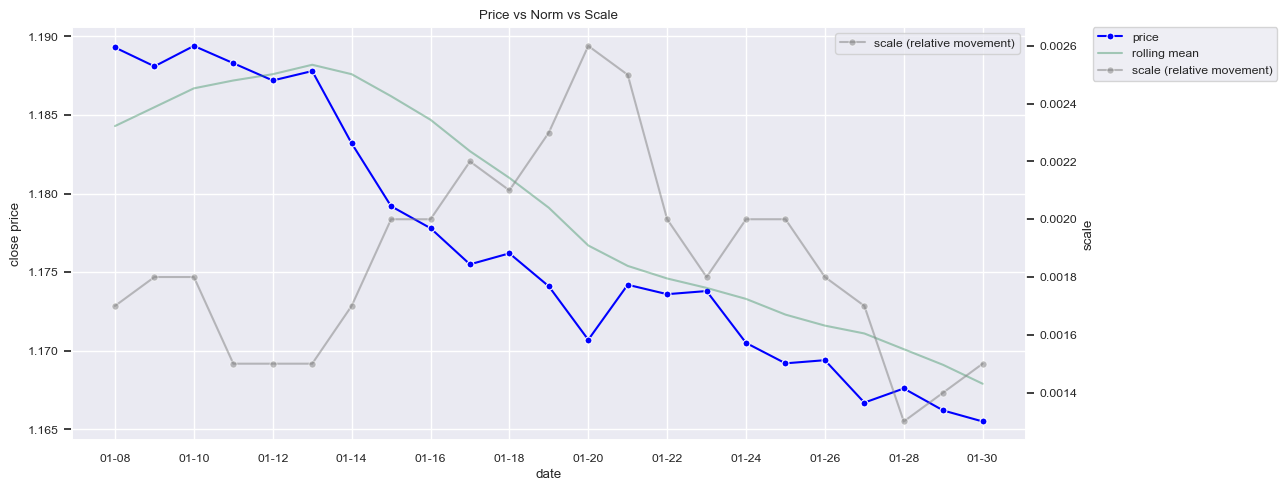

(             close  roll_mean   scale
 date                                 
 2015-01-08  1.1893     1.1843  0.0017
 2015-01-09  1.1881     1.1855  0.0018
 2015-01-10  1.1894     1.1867  0.0018
 2015-01-11  1.1883     1.1872  0.0015
 2015-01-12  1.1872     1.1876  0.0015
 2015-01-13  1.1878     1.1882  0.0015
 2015-01-14  1.1832     1.1876  0.0017
 2015-01-15  1.1792     1.1862  0.0020
 2015-01-16  1.1778     1.1847  0.0020
 2015-01-17  1.1755     1.1827  0.0022
 2015-01-18  1.1762     1.1810  0.0021
 2015-01-19  1.1741     1.1791  0.0023
 2015-01-20  1.1707     1.1767  0.0026
 2015-01-21  1.1742     1.1754  0.0025
 2015-01-22  1.1736     1.1746  0.0020
 2015-01-23  1.1738     1.1740  0.0018
 2015-01-24  1.1705     1.1733  0.0020
 2015-01-25  1.1692     1.1723  0.0020
 2015-01-26  1.1694     1.1716  0.0018
 2015-01-27  1.1667     1.1711  0.0017
 2015-01-28  1.1676     1.1701  0.0013
 2015-01-29  1.1662     1.1691  0.0014
 2015-01-30  1.1655     1.1679  0.0015,
 {'correlation': np.floa

In [51]:
def run_high_scale_experiment():
    
    # 1. Generate data
    df = generate_market_simulator()
    
    # 2. Pass data to generate variables
    val = plot_market_regime_view(df)
    
    # 3. Pass to chart function
    vs = plot_price_norm_scale(val)
    
    # 4. Pass to visualize and get correlation
    corr = close_scale_correlation(vs)

    return val, corr

run_high_scale_experiment()